In [91]:
import numpy as np
from glob import glob
from ultralytics import YOLO
from yaml import safe_load
import matplotlib.pyplot as plt
import albumentations as A
import cv2
import warnings as warn
import os
import torch
warn.simplefilter('ignore')

In [ ]:
DS_PATH= r'..\..\..\..\World Of Datasets\Un-Structured Datasets\Object Detection\Drones Detection Dataset\drone_dataset'
DATA_YAML_PATH = os.path.join(DS_PATH,'data.yaml') 

with open(DATA_YAML_PATH, 'r', encoding='utf-8') as file:
    yaml_data = safe_load(file)
yaml_data

{'names': ['drone'],
 'nc': 1,
 'train': '\\train\\images',
 'val': '\\valid\\images'}

In [ ]:
new_train_path = os.path.join(DS_PATH, 'train', 'images')
new_val_path = os.path.join(DS_PATH, 'valid', 'images')

yaml_data['train'] = new_train_path
yaml_data['val'] = new_val_path

yaml_data

{'names': ['drone'],
 'nc': 1,
 'train': '..\\..\\..\\..\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Drones Detection Dataset\\drone_dataset\\train\\images',
 'val': '..\\..\\..\\..\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Drones Detection Dataset\\drone_dataset\\valid\\images'}

In [ ]:
CONF= 0.40

EPOCHS = 30
IMG_SIZE = 380
BATCH_SIZE = 32
OPTIMIZER = 'adam'
LR0 = 1e-3
PATIENCE = 5
PLOTS = True
SAVE_WEIGHTS = True
NAME = 'Drones_Detected_Results'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_OF_WORKERS = 0
TRANSFORMS = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),

                A.OneOf([
                    A.GaussianBlur(blur_limit=3, p=1.0),
                    A.MotionBlur(blur_limit=5, p=1.0),
                ], p=0.3),

                A.OneOf([
                    A.CoarseDropout(
                        num_holes_range=(1, 2),
                        hole_height_range=(60, 120),
                        hole_width_range=(60, 120),
                        fill="random",
                        p=1.0
                    ),
                    A.GridDropout(ratio=0.4, random_offset=True, p=1.0),
                ], p=0.4),

                A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),

                A.Rotate(limit=30, p=0.5),
                A.Affine(shear=(-10, 10), p=0.3),

                A.RandomShadow(p=0.2),
                A.ImageCompression(quality_range=(70, 100), p=0.2),
                A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
            ])


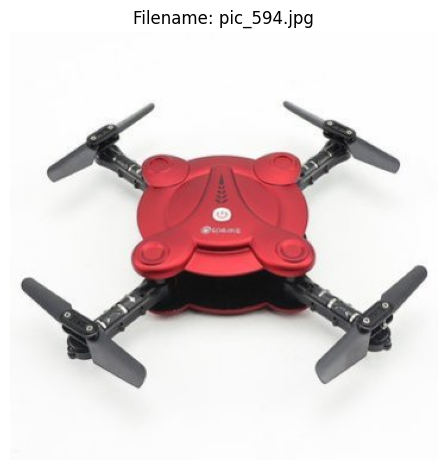

In [ ]:
def show_rand_img(path):
    imgs_items = os.listdir(path)
    rand_img = np.random.choice(imgs_items)
    plt.imshow(plt.imread(os.path.join(path,rand_img)))
    plt.title(f"Filename: {rand_img}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
show_rand_img(yaml_data['train'])

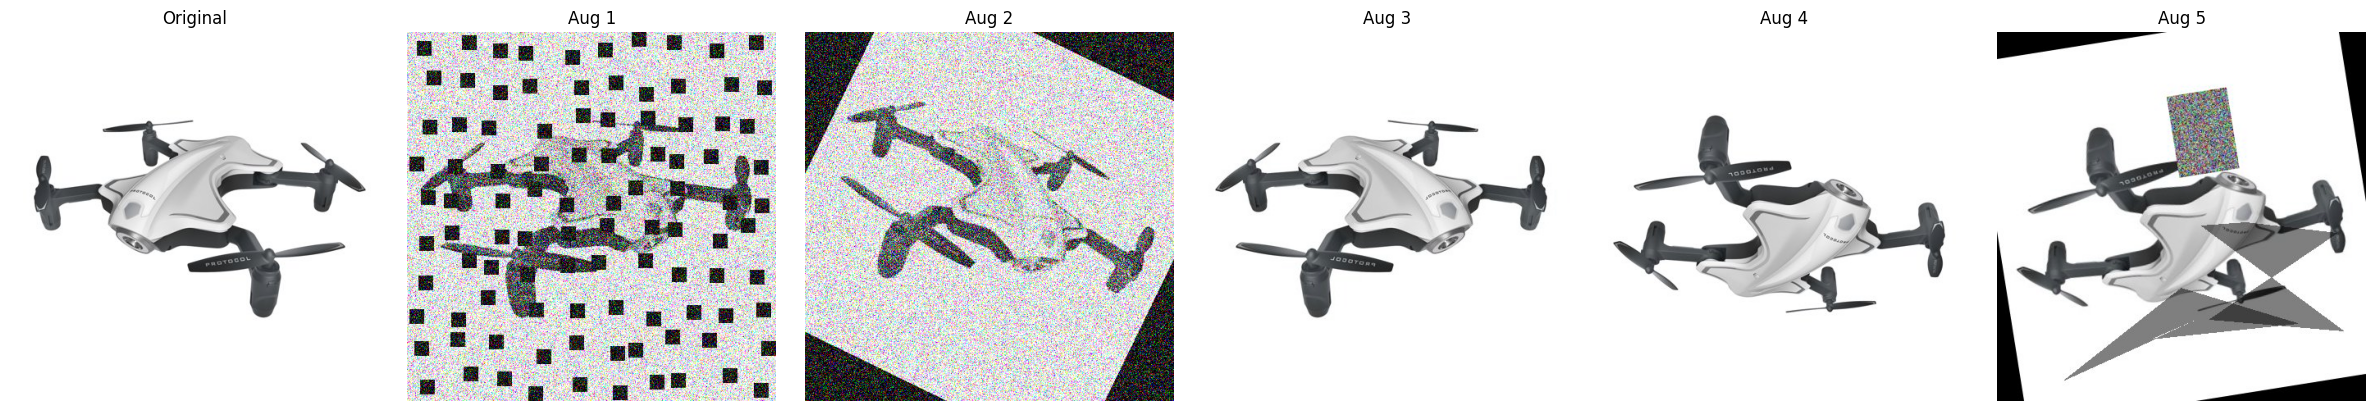

In [ ]:
def show_augmentations(path, transforms, n=5):
    imgs_items = os.listdir(path)
    rand_img = np.random.choice(imgs_items)
    image = cv2.imread(os.path.join(path,rand_img),cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, n + 1, figsize=(4 * (n + 1), 4))

    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i in range(1, n + 1):
        augmented = transforms(image=image)["image"]
        axes[i].imshow(augmented)
        axes[i].set_title(f"Aug {i}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_augmentations(yaml_data['train'], TRANSFORMS, n=5)